In [1]:
from IPython import get_ipython
from IPython.display import display
import torchvision
import torch.utils.data as utils
from torchvision import datasets, models, transforms
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from torch.cuda.amp import autocast, GradScaler
from torch.nn.parallel import DistributedDataParallel as DDP
import seaborn as sns
from tqdm import tqdm
import timm
from torch.jit import script

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
def imshow(img,text=None,should_save=False):
    npimg = img.numpy()
    plt.axis("off")
    if text:
        plt.text(75, 8, text, style='italic',fontweight='bold',
            bbox={'facecolor':'white', 'alpha':0.8, 'pad':10})
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

def show_plot(iteration,loss):
    plt.plot(iteration,loss)
    plt.show()

In [5]:
class EnhancedConfig:
    # Reduced batch size and model complexity
    training_dirs = '/content/drive/MyDrive/DataSet/train'
    testing_dirs = '/content/drive/MyDrive/DataSet/test'
    train_batch_size = 16  # Reduced from 32
    test_batch_size = 16   # Added separate test batch size
    train_number_epochs = 20
    patience = 10
    num_workers = 2        # Reduced from 4
    learning_rate = 1e-4
    weight_decay = 0.01
    embedding_dim = 128    # Reduced from 256
    dropout_rate = 0.4
    pos_weight = 0.5
    margin = 1.0
    image_size = 160      # Reduced from 224
    mixup_alpha = 0.2
    pin_memory = False    # Disable pin_memory to reduce memory usage

In [6]:
class ImprovedContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0, pos_weight=0.5):
        super(ImprovedContrastiveLoss, self).__init__()
        self.margin = margin
        self.pos_weight = pos_weight

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2)
        pos_loss = (1 - label) * torch.pow(euclidean_distance, 2)
        neg_loss = label * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2)
        loss = self.pos_weight * pos_loss + (1 - self.pos_weight) * neg_loss
        return torch.mean(loss)

In [7]:
class FeaturePyramidNetwork(nn.Module):
    def __init__(self, in_channels_list, out_channels):
        super(FeaturePyramidNetwork, self).__init__()
        self.lateral_convs = nn.ModuleList()
        self.fpn_convs = nn.ModuleList()

        for in_channels in in_channels_list:
            # Add intermediate convolutional layer to match channels
            self.lateral_convs.append(nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ))

            self.fpn_convs.append(nn.Sequential(
                nn.Conv2d(out_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ))

    def forward(self, features):
        laterals = []
        for feature, lateral_conv in zip(features, self.lateral_convs):
            laterals.append(lateral_conv(feature))

        fpn_features = []
        for lateral, fpn_conv in zip(laterals, self.fpn_convs):
            fpn_features.append(fpn_conv(lateral))
        return fpn_features

In [8]:
class LightweightSiameseNetwork(nn.Module):
    def __init__(self, embedding_dim=128, dropout_rate=0.4):
        super(LightweightSiameseNetwork, self).__init__()

        # Using a lighter base model
        self.base_model = timm.create_model('efficientnet_lite0', pretrained=True)
        self.base_model.conv_stem = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)

        # Simplified feature extraction
        self.feature_extractor = nn.Sequential(
            self.base_model.conv_stem,
            self.base_model.bn1,
            self.base_model.blocks[0],
            self.base_model.blocks[1]
        )

        # Get the output channels from the feature extractor
        # Use a dummy input to determine the shape
        dummy_input = torch.randn(1, 1, EnhancedConfig.image_size, EnhancedConfig.image_size)
        dummy_features = self.feature_extractor(dummy_input)
        feature_channels = dummy_features.shape[1]  # Get the number of channels

        # Simplified embedding layers
        # Change the input dimension of the linear layer to feature_channels
        self.embedding_layers = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(feature_channels, embedding_dim), # Use dynamic feature_channels
            nn.BatchNorm1d(embedding_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(embedding_dim, embedding_dim)
        )

        self.final_norm = nn.LayerNorm(embedding_dim)

    def forward_once(self, x):
        x = self.feature_extractor(x)
        x = self.embedding_layers(x)
        x = self.final_norm(x)
        return F.normalize(x, p=2, dim=1)

    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

In [9]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x).squeeze(-1).squeeze(-1))
        max_out = self.fc(self.max_pool(x).squeeze(-1).squeeze(-1))
        out = torch.sigmoid(avg_out + max_out).unsqueeze(2).unsqueeze(3)
        return out

In [10]:
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2)

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)
        return torch.sigmoid(x)

In [11]:
class SiameseNetworkDataset(Dataset):
    def __init__(self, training_csv=None, training_dir=None, transform=None):
        self.training_df = pd.read_csv(training_csv)
        self.training_df.columns = ["image1", "image2", "label"]
        self.training_dir = training_dir
        self.transform = transform
        self.images = {}
        self._preload_images()

    def _preload_images(self):
        print("Preloading images...")
        for idx in tqdm(range(len(self.training_df))):
            img1_path = os.path.join(self.training_dir, self.training_df.iat[idx, 0]).replace("\\", "/").replace('"', '')
            img2_path = os.path.join(self.training_dir, self.training_df.iat[idx, 1]).replace("\\", "/").replace('"', '')

            if img1_path not in self.images:
                self.images[img1_path] = self.transform(Image.open(img1_path).convert("L"))
            if img2_path not in self.images:
                self.images[img2_path] = self.transform(Image.open(img2_path).convert("L"))

    def __getitem__(self, index):
        img1_path = os.path.join(self.training_dir, self.training_df.iat[index, 0]).replace("\\", "/").replace('"', '')
        img2_path = os.path.join(self.training_dir, self.training_df.iat[index, 1]).replace("\\", "/").replace('"', '')

        return (self.images[img1_path],
                self.images[img2_path],
                torch.tensor([int(self.training_df.iat[index, 2])], dtype=torch.float32))

    def __len__(self):
        return len(self.training_df)

In [48]:
# تحميل بيانات التدريب
train_csv = "/content/drive/MyDrive/DataSet/train_data.csv"
train_dir = "/content/drive/MyDrive/DataSet/train"

# Define the transformations
train_transform = transforms.Compose([
    transforms.Resize((105, 105)),  # Or your desired size
    transforms.ToTensor()
])

# Instantiate the dataset with the transform
train_dataset = SiameseNetworkDataset(training_csv=train_csv, training_dir=train_dir, transform=train_transform)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

Preloading images...


100%|██████████| 23205/23205 [00:11<00:00, 1982.17it/s]


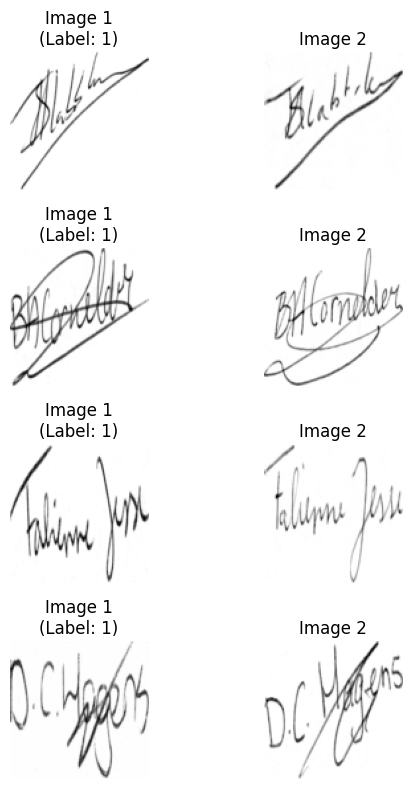

In [49]:
def visualize_dataset(dataset, num_samples=4):
    """
    دالة لعرض عينات من بيانات SiameseNetworkDataset.

    :param dataset: كائن Dataset يحتوي على صور مزدوجة وتصنيفات.
    :param num_samples: عدد الأزواج التي سيتم عرضها.
    """
    fig, axes = plt.subplots(num_samples, 2, figsize=(6, num_samples * 2))

    for i in range(num_samples):
        # اختيار عينة عشوائية
        idx = torch.randint(0, len(dataset), (1,)).item()
        img0, img1, label = dataset[idx]

        # تحويل الصور إلى NumPy للعرض
        img0 = img0.squeeze().cpu().numpy()
        img1 = img1.squeeze().cpu().numpy()

        # عرض الصورة الأولى
        axes[i, 0].imshow(img0, cmap="gray")
        axes[i, 0].set_title(f"Image 1\n(Label: {int(label.item())})")
        axes[i, 0].axis("off")

        # عرض الصورة الثانية
        axes[i, 1].imshow(img1, cmap="gray")
        axes[i, 1].set_title("Image 2")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

# استدعاء الدالة لعرض 5 عينات من الداتا سيت
visualize_dataset(train_dataset, num_samples=4)

In [14]:
class EarlyStopping:
    def __init__(self, patience=7, delta=0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [15]:
def mixup_data(x1, x2, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x1.size()[0]
    index = torch.randperm(batch_size).cuda()

    mixed_x1 = lam * x1 + (1 - lam) * x1[index]
    mixed_x2 = lam * x2 + (1 - lam) * x2[index]
    mixed_y = lam * y + (1 - lam) * y[index]

    return mixed_x1, mixed_x2, mixed_y

In [16]:
def train_and_evaluate(training_csv, testing_csv, training_dir, testing_dir):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.backends.cudnn.benchmark = True

    # Set memory optimization flags
    torch.cuda.empty_cache()
    if device.type == 'cuda':
        torch.backends.cudnn.enabled = True
        torch.backends.cudnn.benchmark = True

    # Simplified data transformation
    train_transform = transforms.Compose([
        transforms.Grayscale(1),
        transforms.Resize((EnhancedConfig.image_size, EnhancedConfig.image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485], std=[0.229])
    ])

    test_transform = transforms.Compose([
        transforms.Grayscale(1),
        transforms.Resize((EnhancedConfig.image_size, EnhancedConfig.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485], std=[0.229])
    ])

    # Create datasets and dataloaders with memory optimizations
    train_dataset = SiameseNetworkDataset(
        training_csv=training_csv,
        training_dir=training_dir,
        transform=train_transform
    )

    test_dataset = SiameseNetworkDataset(
        training_csv=testing_csv,
        training_dir=testing_dir,
        transform=test_transform
    )

    train_dataloader = DataLoader(
        train_dataset,
        batch_size=EnhancedConfig.train_batch_size,
        shuffle=True,
        num_workers=EnhancedConfig.num_workers,
        pin_memory=EnhancedConfig.pin_memory
    )

    test_dataloader = DataLoader(
        test_dataset,
        batch_size=EnhancedConfig.test_batch_size,
        shuffle=False,
        num_workers=EnhancedConfig.num_workers,
        pin_memory=EnhancedConfig.pin_memory
    )

    # Initialize model with reduced complexity
    model = LightweightSiameseNetwork(
        embedding_dim=EnhancedConfig.embedding_dim,
        dropout_rate=EnhancedConfig.dropout_rate
    ).to(device)

    criterion = ImprovedContrastiveLoss(
        margin=EnhancedConfig.margin,
        pos_weight=EnhancedConfig.pos_weight
    )

    optimizer = optim.AdamW(
        model.parameters(),
        lr=EnhancedConfig.learning_rate,
        weight_decay=EnhancedConfig.weight_decay
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5,
        verbose=True
    )

    scaler = GradScaler()
    early_stopping = EarlyStopping(patience=EnhancedConfig.patience)

    # Memory-efficient training loop
    print("Starting training...")
    for epoch in range(EnhancedConfig.train_number_epochs):
        model.train()
        epoch_loss = 0

        # Clear cache at the start of each epoch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        for i, (img0, img1, label) in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch+1}")):
            img0, img1, label = img0.to(device), img1.to(device), label.to(device)

            with autocast():
                output1, output2 = model(img0, img1)
                loss = criterion(output1, output2, label)

            optimizer.zero_grad(set_to_none=True)  # Memory efficient gradient clearing
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()

            # Clear variables to free memory
            del output1, output2, loss
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        avg_loss = epoch_loss / len(train_dataloader)
        print(f"Epoch {epoch+1}, Average Loss: {avg_loss:.4f}")

        # Memory efficient validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for img0, img1, label in test_dataloader:
                img0, img1, label = img0.to(device), img1.to(device), label.to(device)
                output1, output2 = model(img0, img1)
                loss = criterion(output1, output2, label)
                val_loss += loss.item()

                # Clear variables
                del output1, output2, loss
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

        val_loss /= len(test_dataloader)
        print(f"Validation Loss: {val_loss:.4f}")

        scheduler.step(val_loss)
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break

    # Find optimal threshold and evaluate with memory efficiency
    print("\nFinding optimal threshold...")
    optimal_threshold = find_optimal_threshold(model, test_dataloader, device)
    print(f"Optimal threshold: {optimal_threshold:.4f}")

    print("\nEvaluating model...")
    metrics = evaluate_model(model, test_dataloader, device, optimal_threshold)

    return model, metrics, optimal_threshold

In [17]:
def evaluate_model(model, dataloader, device, threshold=0.5):
    model.eval()
    y_true = []
    y_pred = []
    distances = []

    with torch.no_grad():
        for img0, img1, label in tqdm(dataloader, desc="Evaluating"):
            img0, img1, label = img0.to(device), img1.to(device), label.to(device)

            output1, output2 = model(img0, img1)
            distance = F.pairwise_distance(output1, output2)
            prediction = (distance > threshold).float()

            y_true.extend(label.cpu().numpy().flatten())
            y_pred.extend(prediction.cpu().numpy().flatten())
            distances.extend(distance.cpu().numpy().flatten())

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    conf_matrix = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Plot distance distribution
    plt.figure(figsize=(10, 6))
    for i, label in enumerate(['Similar', 'Different']):
        mask = np.array(y_true) == i
        plt.hist(np.array(distances)[mask], bins=50, alpha=0.5, label=label)
    plt.title('Distance Distribution')
    plt.xlabel('Distance')
    plt.ylabel('Count')
    plt.legend()
    plt.show()
    return {
        'accuracy': accuracy * 100,
        'precision': precision * 100,
        'recall': recall * 100,
        'f1': f1 * 100
    }
    y_pred = []
    distances = []

    with torch.no_grad():
        for img0, img1, label in tqdm(dataloader, desc="Evaluating"):
            img0, img1, label = img0.to(device), img1.to(device), label.to(device)

            output1, output2 = model(img0, img1)
            distance = F.pairwise_distance(output1, output2)
            prediction = (distance > threshold).float()

            y_true.extend(label.cpu().numpy().flatten())
            y_pred.extend(prediction.cpu().numpy().flatten())
            distances.extend(distance.cpu().numpy().flatten())

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    conf_matrix = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Plot distance distribution
    plt.figure(figsize=(10, 6))
    for i, label in enumerate(['Similar', 'Different']):
        mask = np.array(y_true) == i
        plt.hist(np.array(distances)[mask], bins=50, alpha=0.5, label=label)
    plt.title('Distance Distribution')
    plt.xlabel('Distance')
    plt.ylabel('Count')
    plt.legend()
    plt.show()
    return {
        'accuracy': accuracy * 100,
        'precision': precision * 100,
        'recall': recall * 100,
        'f1': f1 * 100
    }

In [18]:
def find_optimal_threshold(model, dataloader, device):
    model.eval()
    all_distances = []
    all_labels = []

    with torch.no_grad():
        for img0, img1, label in tqdm(dataloader, desc="Finding optimal threshold"):
            img0, img1, label = img0.to(device), img1.to(device), label.to(device)
            output1, output2 = model(img0, img1)
            distance = F.pairwise_distance(output1, output2)

            all_distances.extend(distance.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    # Try different thresholds to find the optimal one
    thresholds = np.linspace(0.1, 2.0, 100)
    best_accuracy = 0
    best_threshold = 0.5

    for threshold in thresholds:
        predictions = (np.array(all_distances) > threshold).astype(float)
        accuracy = accuracy_score(all_labels, predictions)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = threshold

    return best_threshold

In [19]:
def save_model_with_info(model, metrics, optimal_threshold, save_path):
    """Save the model along with training metrics and optimal threshold"""
    model_info = {
        'state_dict': model.state_dict(),
        'metrics': metrics,
        'optimal_threshold': optimal_threshold,
        'config': {
            'embedding_dim': EnhancedConfig.embedding_dim,
            'dropout_rate': EnhancedConfig.dropout_rate,
            'image_size': EnhancedConfig.image_size
        }
    }
    torch.save(model_info, save_path)
    print(f"Model saved successfully to {save_path}")

In [20]:
def load_model_with_info(save_path, device):
    """Load the model along with its training info"""
    model_info = torch.load(save_path, map_location=device)

    model = EnhancedSiameseNetwork(
        embedding_dim=model_info['config']['embedding_dim'],
        dropout_rate=model_info['config']['dropout_rate']
    ).to(device)

    model.load_state_dict(model_info['state_dict'])
    return model, model_info['metrics'], model_info['optimal_threshold']

Preloading images...


100%|██████████| 23205/23205 [00:11<00:00, 1984.61it/s]


Preloading images...


100%|██████████| 5747/5747 [03:13<00:00, 29.71it/s]
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

...

Epoch 20, Average Loss: 0.1242


Validation Loss: 0.1374

Finding optimal threshold...


Finding optimal threshold: 100%|██████████| 360/360 [00:04<00:00, 89.59it/s]


Optimal threshold: 0.2152

Evaluating model...


Evaluating: 100%|██████████| 360/360 [00:04<00:00, 89.28it/s]


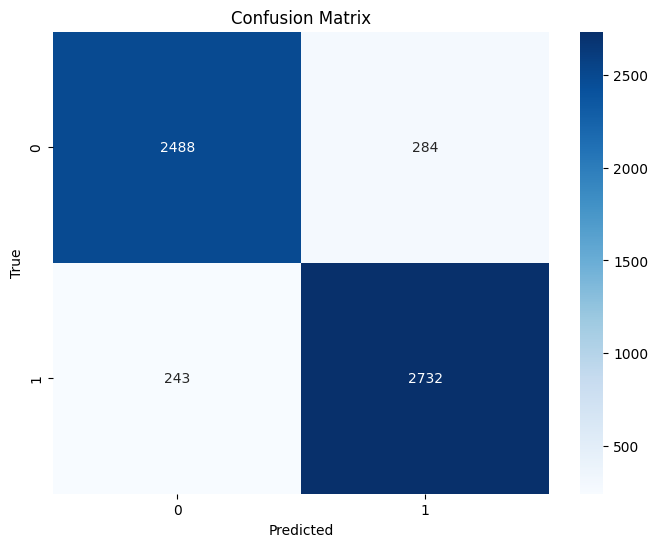

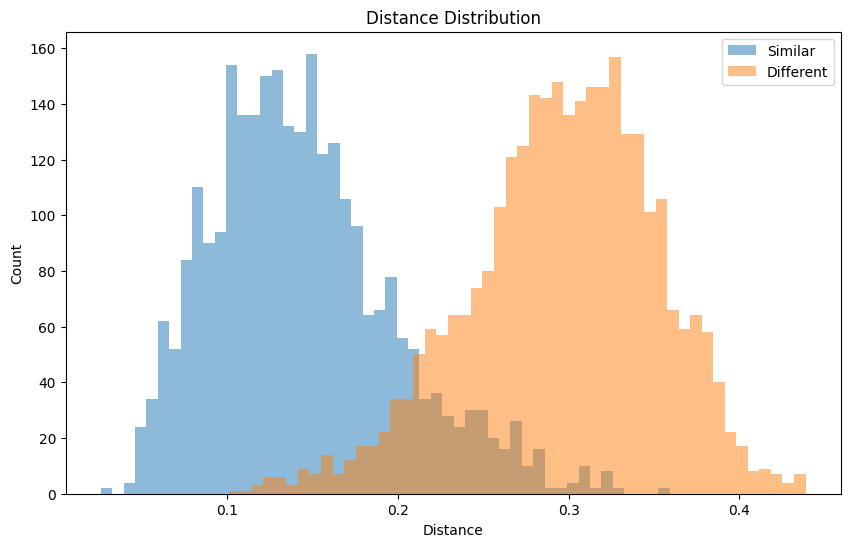

Model saved successfully to enhanced_siamese_model.pt


In [21]:
if __name__ == "__main__":
    # Set random seeds for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    # File paths
    training_csv = '/content/drive/MyDrive/DataSet/train_data.csv'
    testing_csv = '/content/drive/MyDrive/DataSet/test_data.csv'
    training_dir = '/content/drive/MyDrive/DataSet/train'
    testing_dir = '/content/drive/MyDrive/DataSet/test'
    model_save_path = 'enhanced_siamese_model.pt'

    # Train and evaluate the model
    model, metrics, optimal_threshold = train_and_evaluate(
        training_csv,
        testing_csv,
        training_dir,
        testing_dir
    )

    # Save the model with all relevant information
    save_model_with_info(model, metrics, optimal_threshold, model_save_path)

    # Optional: Load the model for inference
    # loaded_model, loaded_metrics, loaded_threshold = load_model_with_info(model_save_path, device)

In [22]:
print(f"Accuracy: {metrics['accuracy']:.2f}%")  # Print accuracy here
print(f"Precision: {metrics['precision']:.2f}%")
print(f"Recall: {metrics['recall']:.2f}%")
print(f"F1 Score: {metrics['f1']:.2f}%")

Accuracy: 90.83%
Precision: 90.58%
Recall: 91.83%
F1 Score: 91.20%


# **Convert model to torchscript**

In [23]:
class ChannelAttention(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = self.fc(self.avg_pool(x).squeeze(-1).squeeze(-1))
        max_out = self.fc(self.max_pool(x).squeeze(-1).squeeze(-1))
        out = torch.sigmoid(avg_out + max_out).unsqueeze(2).unsqueeze(3)
        return out

In [24]:
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)
        return torch.sigmoid(x)

In [25]:
class TorchScriptSiameseNetwork(nn.Module):
    def __init__(self, embedding_dim: int = 128, dropout_rate: float = 0.4):
        super().__init__()

        # Base model initialization
        self.base_model = timm.create_model('efficientnet_lite0', pretrained=True)
        self.base_model.conv_stem = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)

        # Feature extraction layers
        self.feature_extractor = nn.Sequential(
            self.base_model.conv_stem,
            self.base_model.bn1,
            self.base_model.blocks[0],
            self.base_model.blocks[1]
        )

        # Get feature channels dynamically
        with torch.no_grad():
            dummy_input = torch.randn(1, 1, 160, 160)
            dummy_features = self.feature_extractor(dummy_input)
            feature_channels = dummy_features.shape[1]

        # Embedding layers
        self.embedding_layers = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(feature_channels, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(embedding_dim, embedding_dim)
        )

        self.final_norm = nn.LayerNorm(embedding_dim)

        # Add attention mechanisms
        self.channel_attention = ChannelAttention(feature_channels)
        self.spatial_attention = SpatialAttention()

    def forward_once(self, x: torch.Tensor) -> torch.Tensor:
        # Feature extraction
        x = self.feature_extractor(x)

        # Apply attention mechanisms
        channel_weights = self.channel_attention(x)
        x = x * channel_weights
        spatial_weights = self.spatial_attention(x)
        x = x * spatial_weights

        # Generate embeddings
        x = self.embedding_layers(x)
        x = self.final_norm(x)
        return F.normalize(x, p=2, dim=1)

    def forward(self, input1: torch.Tensor, input2: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

In [30]:
def convert_model_to_torchscript(model_path: str, script_save_path: str, device: str = 'cuda') -> None:
    """
    Convert a trained PyTorch model to TorchScript format

    Args:
        model_path: Path to the saved PyTorch model
        script_save_path: Path to save the TorchScript model
        device: Device to use for conversion ('cuda' or 'cpu')
    """
    # Set device
    device = torch.device(device if torch.cuda.is_available() and device == 'cuda' else 'cpu')

    # Load model info
    print(f"Loading model from {model_path}...")
    model_info = torch.load(model_path, map_location=device)

    # Create model instance
    print("Creating model instance...")
    # Use the original model class, LightweightSiameseNetwork
    model = LightweightSiameseNetwork(
        embedding_dim=model_info['config']['embedding_dim'],
        dropout_rate=model_info['config']['dropout_rate']
    ).to(device)

    # Load state dict
    model.load_state_dict(model_info['state_dict'])
    model.eval()

    # Create example inputs
    print("Creating example inputs...")
    example_input1 = torch.randn(1, 1, model_info['config']['image_size'],
                              model_info['config']['image_size']).to(device)
    example_input2 = torch.randn(1, 1, model_info['config']['image_size'],
                              model_info['config']['image_size']).to(device)

    # Trace the model with example inputs
    print("Tracing model...")
    with torch.no_grad():
        traced_script_module = torch.jit.trace(model, (example_input1, example_input2))

    # Save the traced model
    print(f"Saving TorchScript model to {script_save_path}...")
    traced_script_module.save(script_save_path)

    # Save additional model info
    info_path = os.path.splitext(script_save_path)[0] + "_info.pt"
    torch.save({
        'metrics': model_info['metrics'],
        'optimal_threshold': model_info['optimal_threshold'],
        'config': model_info['config']
    }, info_path)

    print("Conversion complete!")

In [31]:
class SiameseInference:
    """Class for performing inference with a TorchScript Siamese network"""

    def __init__(self, model_path: str, info_path: str = None, device: str = 'cuda'):
        """
        Initialize the inference class

        Args:
            model_path: Path to the TorchScript model
            info_path: Path to the model info (optional)
            device: Device to use for inference ('cuda' or 'cpu')
        """
        self.device = torch.device(device if torch.cuda.is_available() and device == 'cuda' else 'cpu')

        # Load the TorchScript model
        print(f"Loading TorchScript model from {model_path}...")
        self.model = torch.jit.load(model_path, map_location=self.device)

        # Default threshold
        self.threshold = 0.5
        self.image_size = 160

        # Load model info if available
        if info_path:
            print(f"Loading model info from {info_path}...")
            info = torch.load(info_path, map_location=self.device)
            self.threshold = info['optimal_threshold']
            self.image_size = info['config']['image_size']
            print(f"Using threshold: {self.threshold}, image size: {self.image_size}")

        # Define image transformation
        self.transform = transforms.Compose([
            transforms.Grayscale(1),
            transforms.Resize((self.image_size, self.image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485], std=[0.229])
        ])

    @torch.no_grad()
    def compare_images(self, img1_path: str, img2_path: str) -> dict:
        """
        Compare two images and determine if they are similar

        Args:
            img1_path: Path to the first image
            img2_path: Path to the second image

        Returns:
            Dictionary with comparison results
        """
        # Load and preprocess images
        img1 = Image.open(img1_path).convert("L")
        img2 = Image.open(img2_path).convert("L")

        img1_tensor = self.transform(img1).unsqueeze(0).to(self.device)
        img2_tensor = self.transform(img2).unsqueeze(0).to(self.device)

        # Get embeddings
        embedding1, embedding2 = self.model(img1_tensor, img2_tensor)

        # Calculate distance
        distance = F.pairwise_distance(embedding1, embedding2).item()

        # Determine if images are similar
        is_different = distance > self.threshold

        return {
            'distance': distance,
            'threshold': self.threshold,
            'is_different': bool(is_different),
            'similarity_score': 1.0 - min(distance / (2 * self.threshold), 1.0) if distance <= self.threshold else 0.0
        }

    @torch.no_grad()
    def get_embedding(self, img_path: str) -> torch.Tensor:
        """
        Get the embedding for a single image

        Args:
            img_path: Path to the image

        Returns:
            Embedding tensor
        """
        # Load and preprocess image
        img = Image.open(img_path).convert("L")
        img_tensor = self.transform(img).unsqueeze(0).to(self.device)

        # Forward pass through first half of the network
        # Since we can't directly call forward_once in TorchScript,
        # we'll compare the image with itself and take one embedding
        embedding, _ = self.model(img_tensor, img_tensor)

        return embedding

In [32]:
def batch_embedding_generation(model_path: str, image_dir: str, output_path: str, batch_size: int = 32):
    """
    Generate and save embeddings for all images in a directory

    Args:
        model_path: Path to the TorchScript model
        image_dir: Directory containing images
        output_path: Path to save embeddings
        batch_size: Batch size for processing
    """
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Load the TorchScript model
    model = torch.jit.load(model_path, map_location=device)

    # Define image transformation
    transform = transforms.Compose([
        transforms.Grayscale(1),
        transforms.Resize((160, 160)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485], std=[0.229])
    ])

    # Get list of image files
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Process in batches
    embeddings = {}

    for i in range(0, len(image_files), batch_size):
        batch_files = image_files[i:i+batch_size]
        batch_tensors = []

        # Prepare batch
        for img_file in batch_files:
            img_path = os.path.join(image_dir, img_file)
            img = Image.open(img_path).convert("L")
            img_tensor = transform(img).unsqueeze(0)
            batch_tensors.append(img_tensor)

        # Combine into batch
        batch = torch.cat(batch_tensors, dim=0).to(device)

        # Generate embeddings (compare each image with itself)
        with torch.no_grad():
            for j, img_file in enumerate(batch_files):
                img_tensor = batch[j:j+1]
                embedding, _ = model(img_tensor, img_tensor)
                embeddings[img_file] = embedding.cpu()

    # Save embeddings
    torch.save(embeddings, output_path)
    print(f"Saved embeddings for {len(embeddings)} images to {output_path}")

In [36]:
if __name__ == "__main__":
    # Example usage
    model_path = 'enhanced_siamese_model.pt'
    script_save_path = 'siamese_model_script.pt'

    # Convert model to TorchScript
    convert_model_to_torchscript(model_path, script_save_path)

    # Create inference instance
    info_path = 'siamese_model_script_info.pt'
    inference = SiameseInference(script_save_path, info_path)

    # Compare two images
    # Update with the correct paths to your images
    image1_path = '/content/drive/MyDrive/DataSet/test/049/01_049.png'
    image2_path = '/content/drive/MyDrive/DataSet/test/049/05_049.png'
    result = inference.compare_images(image1_path, image2_path)
    print(f"Comparison result: {result}")

    # Generate embeddings for a directory of images
    # Update with the correct path to your images directory
    batch_embedding_generation(script_save_path, '/content/drive/MyDrive/DataSet/test', 'embeddings.pt')

Loading model from enhanced_siamese_model.pt...
Creating model instance...


<ipython-input-30-52721ca73d3f>:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_info = torch.load(model_path, map_location=device)


Creating example inputs...
Tracing model...
Saving TorchScript model to siamese_model_script.pt...
Conversion complete!
Loading TorchScript model from siamese_model_script.pt...
Loading model info from siamese_model_script_info.pt...
Using threshold: 0.21515151515151515, image size: 160
Comparison result: {'distance': 0.17160570621490479, 'threshold': 0.21515151515151515, 'is_different': False, 'similarity_score': 0.601198006683672}


<ipython-input-31-40bd291b72e6>:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  info = torch.load(info_path, map_location=self.device)


Saved embeddings for 0 images to embeddings.pt


# **TestScript**

In [43]:
def load_model(model_path):
    """Load the trained Siamese model"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_info = torch.load(model_path, map_location=device)

    model = LightweightSiameseNetwork(
        embedding_dim=model_info['config']['embedding_dim'],
        dropout_rate=model_info['config']['dropout_rate']
    ).to(device)

    model.load_state_dict(model_info['state_dict'])
    model.eval()

    return model, model_info['optimal_threshold'], device

def preprocess_image(image_path):
    """Preprocess the image for model input"""
    transform = transforms.Compose([
        transforms.Grayscale(1),
        transforms.Resize((160, 160)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485], std=[0.229])
    ])

    image = Image.open(image_path).convert('L')
    return transform(image).unsqueeze(0)

def test_similarity(model, image1_path, image2_path, threshold, device):
    """Test if two images are similar"""
    with torch.no_grad():
        # Preprocess images
        img1 = preprocess_image(image1_path).to(device)
        img2 = preprocess_image(image2_path).to(device)

        # Get model predictions
        output1, output2 = model(img1, img2)
        distance = F.pairwise_distance(output1, output2).item()

        # Calculate similarity
        is_similar = distance <= threshold

        return {
            'is_similar': bool(is_similar),
            'distance': float(distance)
        }

In [44]:
def visualize_comparison(image1_path, image2_path, result):
    """Visualize the comparison results"""
    # Load images
    img1 = Image.open(image1_path).convert('L')
    img2 = Image.open(image2_path).convert('L')

    # Create figure
    plt.figure(figsize=(12, 4))

    # Plot first image
    plt.subplot(1, 3, 1)
    plt.imshow(img1, cmap='gray')
    plt.title('Image 1')
    plt.axis('off')

    # Plot second image
    plt.subplot(1, 3, 2)
    plt.imshow(img2, cmap='gray')
    plt.title('Image 2')
    plt.axis('off')

    # Create result visualization
    plt.subplot(1, 3, 3)
    result_color = 'green' if result['is_similar'] else 'red'
    result_text = 'SIMILAR' if result['is_similar'] else 'DIFFERENT'

    # Plot result box
    plt.text(0.5, 0.6, result_text,
             horizontalalignment='center',
             color=result_color,
             fontsize=20,
             fontweight='bold')

    plt.text(0.5, 0.4,
             f"Distance: {result['distance']:.3f}",
             horizontalalignment='center',
             fontsize=12)

    plt.axis('off')
    plt.title('Result')

    plt.tight_layout()
    plt.show()

In [45]:
def test_model_efficiency(model, test_pairs, threshold, device):
    """Test model efficiency on multiple pairs"""
    total_time = 0
    results = []

    for pair in test_pairs:
        start_time = time.time()
        result = test_similarity(model, pair[0], pair[1], threshold, device)
        end_time = time.time()

        total_time += (end_time - start_time)
        results.append(result)

    avg_time = total_time / len(test_pairs)
    return {
        'average_processing_time': avg_time,
        'total_pairs_tested': len(test_pairs),
        'results': results
    }

<ipython-input-43-b17b3934bc92>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_info = torch.load(model_path, map_location=device)


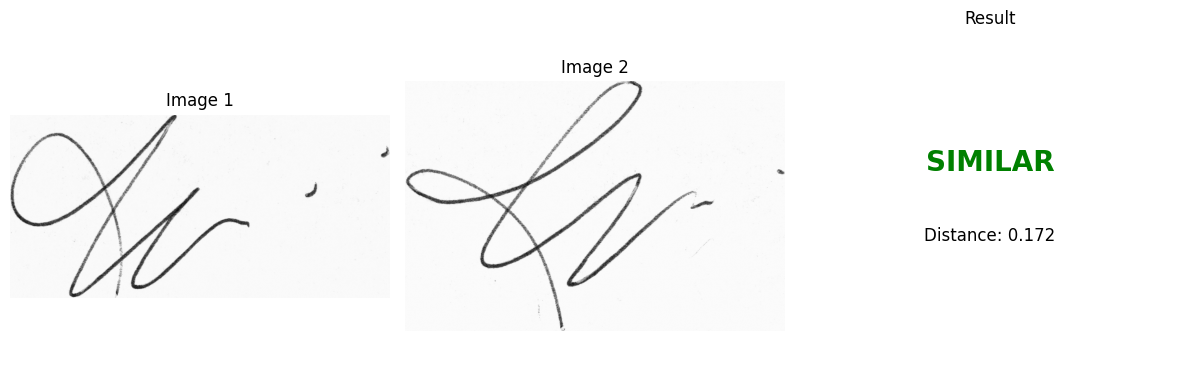


Detailed Results:
Similar: Yes
Distance: 0.172
Threshold: 0.215

Efficiency Results:
Average processing time: 0.033 seconds
Total pairs tested: 2


In [46]:



if __name__ == "__main__":
    # Load model
    model_path = 'enhanced_siamese_model.pt'  # Update with your model path
    model, threshold, device = load_model(model_path)

    # Test single pair
    image1_path = '/content/drive/MyDrive/DataSet/test/049/01_049.png'  # Update with your image paths
    image2_path = '/content/drive/MyDrive/DataSet/test/049/05_049.png'

    # Test and visualize single pair
    result = test_similarity(model, image1_path, image2_path, threshold, device)
    visualize_comparison(image1_path, image2_path, result)

    # Print detailed results
    print("\nDetailed Results:")
    print(f"Similar: {'Yes' if result['is_similar'] else 'No'}")
    print(f"Distance: {result['distance']:.3f}")
    print(f"Threshold: {threshold:.3f}")

    # Test efficiency with multiple pairs
    test_pairs = [
        ('/content/drive/MyDrive/DataSet/test/049/01_049.png', '/content/drive/MyDrive/DataSet/test/049/02_049.png'),
        ('/content/drive/MyDrive/DataSet/test/049_forg/01_0114049.PNG', '/content/drive/MyDrive/DataSet/test/049_forg/01_0206049.PNG'),
        # Add more test pairs as needed
    ]

    efficiency_results = test_model_efficiency(model, test_pairs, threshold, device)

    print("\nEfficiency Results:")
    print(f"Average processing time: {efficiency_results['average_processing_time']:.3f} seconds")
    print(f"Total pairs tested: {efficiency_results['total_pairs_tested']}")